In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

#  Первичный анализ данных (без изменений)
def load_and_explore_data(file_path):
    df = pd.read_csv(
    '/content/all_universities_data_s_0_0_200.csv',
    parse_dates=['Дата архивации'],
    date_parser=lambda x: pd.to_datetime(x, format='%d.%m.%Y %H:%M:%S')
)
    print("=== Первые 5 строк ===")
    print(df.head())
    print("\n=== Информация о данных ===")
    print(df.info())
    print("\n=== Статистика числовых колонок ===")
    print(df.describe())
    cat_cols = ['Программа', 'Уровень', 'Факультет', 'Вуз']
    for col in cat_cols:
        print(f"\n=== Уникальные значения в '{col}' ({df[col].nunique()} шт.) ===")
        print(df[col].value_counts().head(10))
    return df

#  Очистка данных (УДАЛЕНИЕ строк с пропусками)
def clean_data(df):
    # Сохраняем исходное количество строк
    original_rows = df.shape[0]

    # Удаление ВСЕХ строк, где есть хотя бы один пропуск
    df_clean = df.dropna(how='any')

    # Удаление выбросов в 'Стоимость' (верхние 1%)
    upper_limit = df_clean['Стоимость'].quantile(0.99)
    df_clean = df_clean[df_clean['Стоимость'] <= upper_limit]

    # Отчёт о потерянных данных
    cleaned_rows = df_clean.shape[0]
    print(f"\nУдалено строк с пропусками: {original_rows - cleaned_rows}")
    print(f"Осталось строк: {cleaned_rows} ({cleaned_rows/original_rows:.1%} от исходных)")

    return df_clean

#  Feature Engineering
def prepare_features(df):
    df = df.drop(['Дата архивации'], axis=1)
    df['Бюджет_на_место'] = df['Бюджетные места'] / df['Проходной балл'].replace(0, 1)

    # One-Hot для 'Уровень'
    ohe_cols = ['Уровень']
    df = pd.get_dummies(df, columns=ohe_cols)

    # Label Encoding для остальных категорий
    from sklearn.preprocessing import LabelEncoder
    le_cols = ['Программа', 'Факультет', 'Вуз']
    for col in le_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

    # Нормализация числовых признаков
    num_cols = ['Проходной балл', 'Бюджетные места', 'Бюджет_на_место']
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df

file_path = "/content/all_universities_data_s_0_0_200.csv"
df = load_and_explore_data(file_path)
df_clean = clean_data(df)
df_final = prepare_features(df_clean)

print("\n=== Готовые данные ===")
print(df_clean.head())

<ipython-input-1-8da63afc2d33>:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(


=== Первые 5 строк ===
                                           Программа      Уровень  \
0                     Маркетинг и рыночная аналитика  Бакалавриат   
1                       Юриспруденция: частное право  Бакалавриат   
2  Совместный бакалавриат ВШЭ и Центра педагогиче...  Бакалавриат   
3                                Управление бизнесом  Бакалавриат   
4                                             Физика  Бакалавриат   

                      Факультет  Проходной балл  Бюджетные места  Стоимость  \
0  Высшая школа бизнеса НИУ ВШЭ            96.3               25   550000.0   
1       Факультет права НИУ ВШЭ            95.8               30   490000.0   
2  Факультет математики НИУ ВШЭ            94.3               25   400000.0   
3  Высшая школа бизнеса НИУ ВШЭ            93.0               60   550000.0   
4      Факультет физики НИУ ВШЭ            90.3               50   440000.0   

                                                 Вуз      Дата архивации  
0  Националь

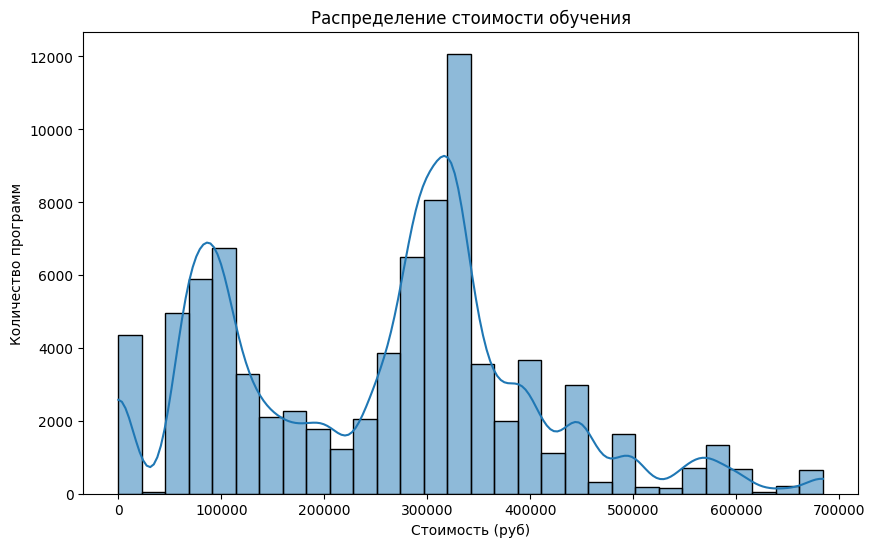

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Стоимость'], kde=True, bins=30)
plt.title('Распределение стоимости обучения')
plt.xlabel('Стоимость (руб)')
plt.ylabel('Количество программ')
plt.show()

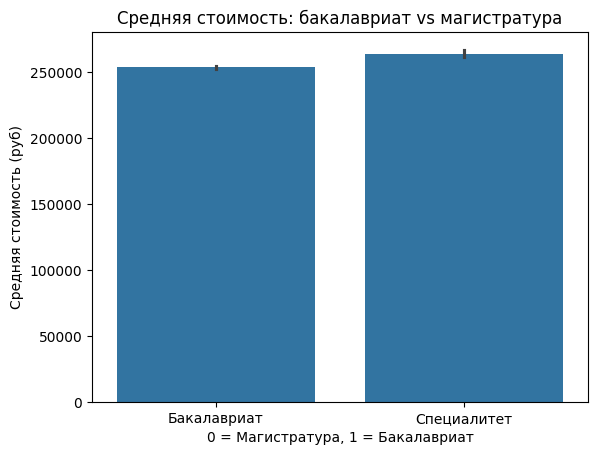

In [ ]:
sns.barplot(data=df_clean, x='Уровень', y='Стоимость')
plt.title('Средняя стоимость: бакалавриат vs магистратура')
plt.xlabel('0 = Магистратура, 1 = Бакалавриат')
plt.ylabel('Средняя стоимость (руб)')
plt.show()

In [ ]:
corr = df_clean.corr(numeric_only=True)['Стоимость'].sort_values(ascending=False)
print(corr)

Стоимость          1.000000
Проходной балл     0.515853
Бюджетные места    0.187985
Name: Стоимость, dtype: float64


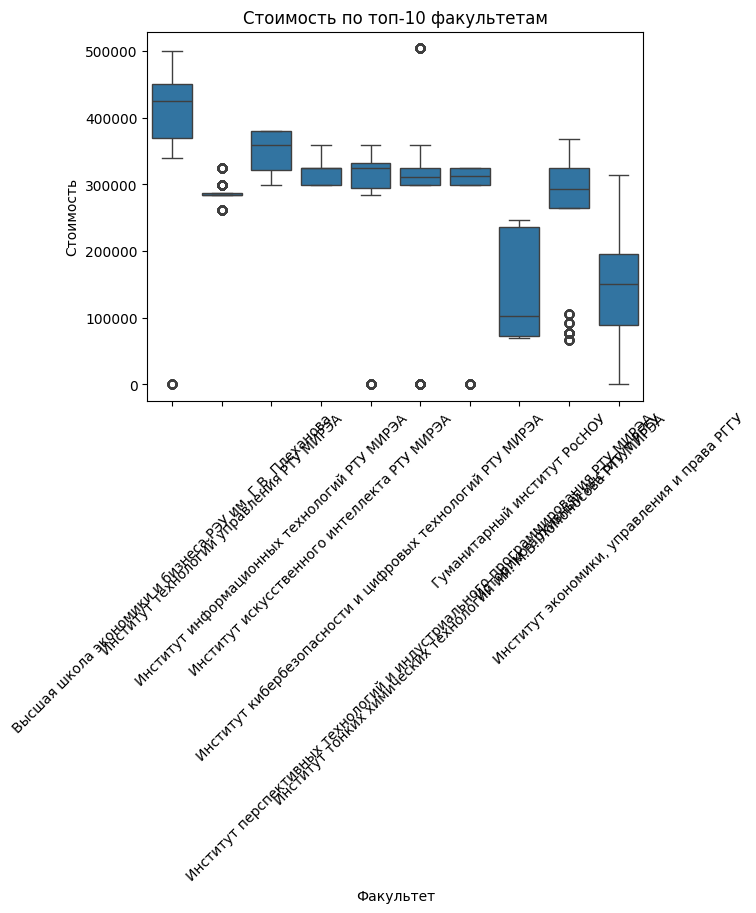

In [ ]:
top_faculties = df_clean['Факультет'].value_counts().nlargest(10).index
sns.boxplot(data=df_clean[df_clean['Факультет'].isin(top_faculties)], x='Факультет', y='Стоимость')
plt.xticks(rotation=45)
plt.title('Стоимость по топ-10 факультетам')
plt.show()

In [ ]:
from scipy.stats import ttest_ind

top_5 = df_clean['Вуз'].value_counts().nlargest(5).index
cost_top5 = df_clean[df_clean['Вуз'].isin(top_5)]['Стоимость']
cost_others = df_clean[~df_clean['Вуз'].isin(top_5)]['Стоимость']

ttest = ttest_ind(cost_top5, cost_others, equal_var=False)
print(f"T-test p-value: {ttest.pvalue:.3f}")

T-test p-value: 0.000


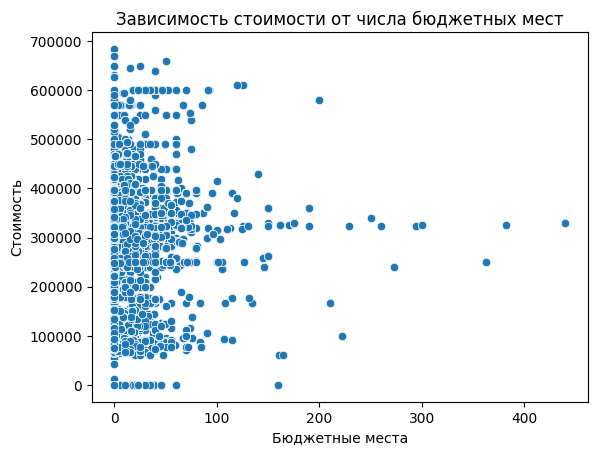

In [ ]:
sns.scatterplot(data=df_clean, x='Бюджетные места', y='Стоимость')
plt.title('Зависимость стоимости от числа бюджетных мест')
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

# Загрузка данных
df = df_clean
# df = df[(df['Стоимость'] >= 60000) & (df['Стоимость'] <= 550000)]
df = df.sort_values('Дата архивации')  # Важно: сортировка по дате!

# Пример данных после сортировки:
print(df[['Дата архивации', 'Программа', 'Стоимость']].head())

         Дата архивации                                          Программа  \
0   2016-02-13 23:35:21                     Маркетинг и рыночная аналитика   
380 2016-02-13 23:35:21                        Искусство  костюма  и  моды   
379 2016-02-13 23:35:21  Сквозные  технологии  и  искусственный  интеллект   
378 2016-02-13 23:35:21                Информационные технологии и  дизайн   
377 2016-02-13 23:35:21                                             Дизайн   

     Стоимость  
0     550000.0  
380   570000.0  
379   320000.0  
378   320000.0  
377   570000.0  


In [ ]:
df_time = df.groupby(['Дата архивации', 'Программа', 'Вуз']).agg({
    'Стоимость': 'mean',
    'Проходной балл': 'mean',
    'Бюджетные места': 'sum'
}).reset_index()

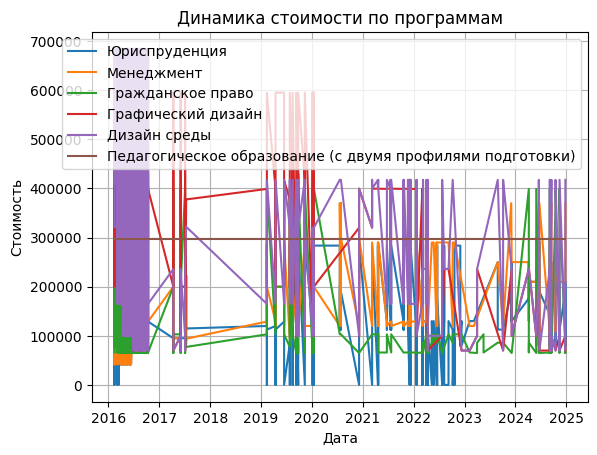

In [ ]:
import matplotlib.pyplot as plt

# Пример: динамика стоимости для топ-3 программ
top_programs = df['Программа'].value_counts().nlargest(6).index
for program in top_programs:
    program_data = df[df['Программа'] == program]
    plt.plot(program_data['Дата архивации'], program_data['Стоимость'], label=program)

plt.title('Динамика стоимости по программам')
plt.xlabel('Дата')
plt.ylabel('Стоимость')
plt.legend()
plt.grid()
plt.show()

In [ ]:
df['Дата архивации'] = pd.to_datetime(df['Дата архивации'], errors='coerce')  # 'coerce' превратит ошибки в NaT

# Проверка пропусков после преобразования
print("Пропуски в дате:", df['Дата архивации'].isna().sum())

Пропуски в дате: 0


In [ ]:
missing_dates = df[df['Дата архивации'].isna()]

print(missing_dates.head(20))

missing_dates.to_csv('пропущенные_даты.csv', index=False, encoding='utf-8')

Empty DataFrame
Columns: [Программа, Уровень, Факультет, Проходной балл, Бюджетные места, Стоимость, Вуз, Дата архивации]
Index: []


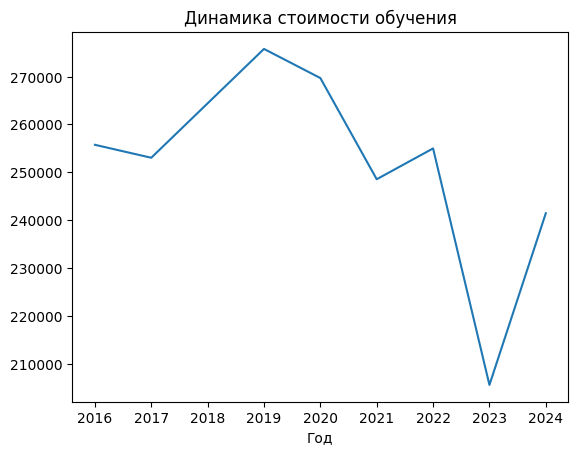

In [ ]:
df = df.dropna(subset=['Дата архивации'])

df['Год'] = df['Дата архивации'].dt.year

yearly_data = df.groupby('Год')['Стоимость'].mean()
yearly_data.plot(title='Динамика стоимости обучения')
plt.show()

In [ ]:
print(df['Дата архивации'].dtype)

datetime64[ns]


In [ ]:
print(df['Дата архивации'].head())  # Должно быть: datetime64[ns]

0     2016-02-13 23:35:21
380   2016-02-13 23:35:21
379   2016-02-13 23:35:21
378   2016-02-13 23:35:21
377   2016-02-13 23:35:21
Name: Дата архивации, dtype: datetime64[ns]


In [ ]:
print(df.head(20))

                                             Программа      Уровень  \
0                       Маркетинг и рыночная аналитика  Бакалавриат   
380                        Искусство  костюма  и  моды  Бакалавриат   
379  Сквозные  технологии  и  искусственный  интеллект  Бакалавриат   
378                Информационные технологии и  дизайн  Бакалавриат   
377                                             Дизайн  Бакалавриат   
376              Музыкально-инструментальное искусство  Бакалавриат   
375  Информационные  технологии  и  искусственный  ...  Бакалавриат   
374                          Теория и история искусств  Бакалавриат   
373                       Дизайн костюма и аксессуаров  Бакалавриат   
372              Искусство концертного исполнительства  Специалитет   
371                    Инструменты эстрадного оркестра  Бакалавриат   
370          Реставрация и  технологическая экспертиза  Бакалавриат   
369                                Вокальное искусство  Бакалавриат   
368   

In [ ]:
print(df.columns.tolist())

['Программа', 'Уровень', 'Факультет', 'Проходной балл', 'Бюджетные места', 'Стоимость', 'Вуз', 'Дата архивации', 'Год']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


# Преобразование даты в числовые признаки
df['Дата архивации'] = pd.to_datetime(df['Дата архивации'])
df['Год'] = df['Дата архивации'].dt.year
df['Месяц'] = df['Дата архивации'].dt.month
df['День'] = df['Дата архивации'].dt.day

# Выбор нужных признаков
features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места', 'Программа', 'Вуз']
X = df[features]
y = df['Стоимость'].values.reshape(-1, 1)  # Преобразуем в 2D-массив

# Масштабируем целевую переменную
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Разделяем признаки на числовые и категориальные
numerical_features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места']
categorical_features = ['Программа', 'Вуз']

# Препроцессинг
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)
X_processed_dense = X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed

In [ ]:
X_reshaped = np.expand_dims(X_processed_dense, axis=1)  # (n_samples, 1, n_features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(1, X_processed_dense.shape[1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.2683 - val_loss: 0.0459
Epoch 2/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0440 - val_loss: 0.0285
Epoch 3/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 0.0285 - val_loss: 0.0213
Epoch 4/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0220 - val_loss: 0.0185
Epoch 5/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0184 - val_loss: 0.0151
Epoch 6/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0168 - val_loss: 0.0130
Epoch 7/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0151 - val_loss: 0.0113
Epoch 8/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0135 - val_loss: 0.0105
Epoch 9/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0120 - val_loss: 0.0100
Epoch 10/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0123 - val_loss: 0.0093
Epoch 11/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0111 - val_loss: 0.0089
Epoch 12/50
2113/21

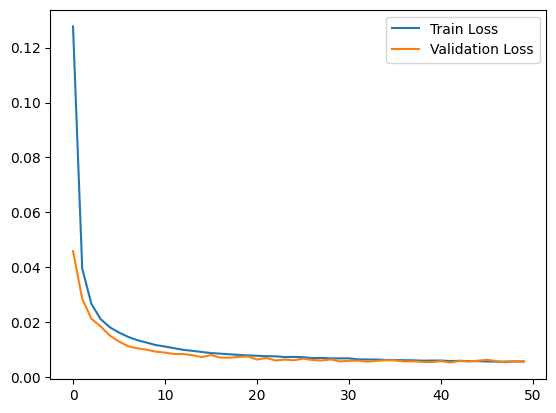

529/529 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
   Реальная стоимость  Предсказанная стоимость
0            120000.0            122272.398438
1            283600.0            281903.000000
2             66000.0             64589.492188
3            340000.0            338602.937500
4            406600.0            399697.687500
5            120000.0            117720.929688
6            284400.0            283807.500000
7             71540.0             71332.820312
8             78000.0             76745.164062
9             66000.0             65593.710938


In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# --- 7. Предсказание и обратное масштабирование ---
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Возвращаем исходный масштаб

# Пример сравнения реальных и предсказанных значений
results = pd.DataFrame({
    'Реальная стоимость': scaler_y.inverse_transform(y_test).flatten(),
    'Предсказанная стоимость': y_pred.flatten()
})
print(results.head(10))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

metrics = {
    "MAE (рубли)": mean_absolute_error(y_test_original, y_pred),
    "MSE (рубли²)": mean_squared_error(y_test_original, y_pred),
    "RMSE (рубли)": np.sqrt(mean_squared_error(y_test_original, y_pred)),
    "R²": r2_score(y_test_original, y_pred),

    # Метрики в масштабированном виде (для сравнения)
    "MAE (scaled)": mean_absolute_error(y_test, y_pred_scaled),
    "MSE (scaled)": mean_squared_error(y_test, y_pred_scaled),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

529/529 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE (рубли): 3638.2684
MSE (рубли²): 126116748.2659
RMSE (рубли): 11230.1713
R²: 0.9941
MAE (scaled): 0.0246
MSE (scaled): 0.0058


In [ ]:
X_test[0:2]

array([[[0.75      , 0.18181818, 0.06666667, ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.72727273, 0.73333333, ..., 0.        ,
         0.        , 0.        ]]])

In [ ]:
from tensorflow.keras.models import save_model

# Сохраняем с указанием custom_objects если есть свои метрики
save_model(
    model,
    'lstm_model.h5',
    save_format='h5',
    include_optimizer=True
)

In [ ]:
from tensorflow.keras.models import load_model
import pickle

# 1. Загружаем модель
model = load_model('lstm_model.h5')

# 2. Загружаем препроцессор
with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

# 3. Загружаем scaler
with open('scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

# 4. Пример использования
def predict_cost(input_data):
    """Функция для предсказания"""
    X_processed = preprocessor.transform(input_data)
    X_reshaped = np.expand_dims(X_processed, axis=1)
    y_pred = model.predict(X_reshaped)
    return scaler_y.inverse_transform(y_pred)[0][0]

TypeError: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}

In [ ]:
import pandas as pd
import numpy as np

input_data = {
    'Год': [2021],
    'Месяц': [6],
    'День': [1],
    'Проходной балл': [20],
    'Бюджетные места': [10],
    'Программа': ['Финансы и кредит'],
    'Вуз': ['Российский новый университет']
}

input_df = pd.DataFrame(input_data)

X_processed = preprocessor.transform(input_df)

X_reshaped = np.expand_dims(X_processed, axis=1)

predicted_cost = model.predict(X_reshaped)
real_cost = scaler_y.inverse_transform(predicted_cost)[0][0]
print(f"Предсказанная стоимость: {real_cost:,.2f} руб.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Предсказанная стоимость: 223,154.56 руб.


In [ ]:
X_processed

array([[0., 0., 0., 0., 0., 1., 1.]])

In [ ]:
import pandas as pd


unique_uni = df['Вуз'].unique()
print(unique_uni)

['Национальный исследовательский университет «Высшая школа экономики»'
 'Московский государственный университет дизайна и технологии'
 'Московский технологический университет (МИРЭА, МГУПИ, МИТХТ)'
 'Московский университет имени С.Ю. Витте' 'Институт бизнеса и дизайна'
 'Институт государственного администрирования'
 'Российский новый университет'
 'Российский экономический университет имени Г.В. Плеханова'
 'Московский технический университет связи и информатики'
 'Государственный университет по землеустройству'
 'Московский городской педагогический университет'
 'Московский государственный институт индустрии туризма имени Ю.А.Сенкевича'
 'Санкт-Петербургский государственный университет'
 'Санкт-Петербургский государственный академический институт живописи, скульптуры и архитектуры имени И. Е. Репина'
 'Балтийская академия туризма и предпринимательства'
 'Ленинградский государственный университет имени А. С. Пушкина'
 'Санкт-Петербургский государственный институт культуры'
 'Санкт-Пете

In [ ]:
connected_programs = df[df['Вуз'] == 'Российский новый университет']['Программа'].unique()

print("Программы МИРЭА — Российский технологический университет:")
for i, program in enumerate(sorted(connected_programs), 1):
    print(f"{i}. {program}")

Программы МИРЭА — Российский технологический университет:
1. HR-менеджмент
2. Архитектура предприятия
3. Беспилотная робототехника и эргономика
4. Гражданское право
5. Дизайн и видео в рекламе
6. Кибербезопасность
7. Логопедия
8. Математическое моделирование и вычислительная математика
9. Менеджмент туристской индустрии
10. Налоги и налогообложение
11. Начальное образование
12. Новые медиа
13. Организация и управление бизнесом
14. Педагог-психолог в системе образования
15. Переводчик в сфере кросс-культурных коммуникаций (английский язык)
16. Переводчик в сфере кросс-культурных коммуникаций (китайский язык)
17. Переводчик в сфере кросс-культурных коммуникаций (японский язык)
18. Прикладная информатика в экономике
19. Психологическое консультирование
20. Редактор средств массовой информации
21. Реклама и связи с общественностью в коммерческом секторе
22. Социальная работа с различными группами населения
23. Специальный перевод как основа межъязыковой профессиональной коммуникации (англи

In [ ]:
df['Год'] = df['Дата архивации'].dt.year
df['Месяц'] = df['Дата архивации'].dt.month
df['Квартал'] = df['Дата архивации'].dt.quarter

# Лаговые признаки
df['Стоимость_lag1'] = df.groupby('Программа')['Стоимость'].shift(1)  # Значение за предыдущий месяц
df['Стоимость_lag12'] = df.groupby('Программа')['Стоимость'].shift(12)  # Для годовой сезонности

# Скользящее среднее
df['Стоимость_rolling_mean'] = df.groupby('Программа')['Стоимость'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Подготовка последовательностей
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])

    # Конвертируем в единый массив NumPy перед созданием тензора
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return torch.FloatTensor(X), torch.FloatTensor(y)

# Нормализация данных
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Стоимость']])

# Создание последовательностей
n_steps = 12
X, y = create_sequences(scaled_data, n_steps)

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Модель LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
        self.linear = nn.Linear(64, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x[:, -1, :])
        return x

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

# Обучение
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.3458
Epoch 1, Loss: 0.1348
Epoch 2, Loss: 0.0726
Epoch 3, Loss: 0.0473
Epoch 4, Loss: 0.0548
Epoch 5, Loss: 0.0545
Epoch 6, Loss: 0.0482
Epoch 7, Loss: 0.0451
Epoch 8, Loss: 0.0481
Epoch 9, Loss: 0.0485
Epoch 10, Loss: 0.0444
Epoch 11, Loss: 0.0426
Epoch 12, Loss: 0.0436
Epoch 13, Loss: 0.0439
Epoch 14, Loss: 0.0417
Epoch 15, Loss: 0.0385
Epoch 16, Loss: 0.0380
Epoch 17, Loss: 0.0389
Epoch 18, Loss: 0.0336
Epoch 19, Loss: 0.0337
Epoch 20, Loss: 0.0321
Epoch 21, Loss: 0.0406
Epoch 22, Loss: 0.0380
Epoch 23, Loss: 0.0421
Epoch 24, Loss: 0.0355
Epoch 25, Loss: 0.0304
Epoch 26, Loss: 0.0344
Epoch 27, Loss: 0.0380
Epoch 28, Loss: 0.0339
Epoch 29, Loss: 0.0306
Epoch 30, Loss: 0.0319
Epoch 31, Loss: 0.0341
Epoch 32, Loss: 0.0337
Epoch 33, Loss: 0.0309
Epoch 34, Loss: 0.0289
Epoch 35, Loss: 0.0297
Epoch 36, Loss: 0.0308
Epoch 37, Loss: 0.0290
Epoch 38, Loss: 0.0270
Epoch 39, Loss: 0.0279
Epoch 40, Loss: 0.0290
Epoch 41, Loss: 0.0276
Epoch 42, Loss: 0.0266
Epoch 43, Loss: 0.028

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
print(f'Test MSE: {test_loss.item():.4f}')

# Денормализация
test_pred = scaler.inverse_transform(test_pred.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Визуализация
plt.plot(y_test_actual, label='Фактическая стоимость')
plt.plot(test_pred, label='Прогноз')
plt.legend()
plt.show()

mae = mean_absolute_error(y_test_actual, test_pred)
r2 = r2_score(y_test_actual, test_pred)

print(f'MAE: {mae:.2f} руб.')
print(f'R2 Score: {r2:.2f}')

AttributeError: 'Sequential' object has no attribute 'eval'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Подготовка данных (адаптация под ваш существующий df)
def prepare_features(df, n_steps=12):
    """Создает временные признаки из вашего DataFrame"""
    # Создаем лаговые признаки
    for i in range(1, n_steps+1):
        df[f'lag_{i}'] = df['Стоимость'].shift(i)

    # Скользящие статистики
    df['rolling_mean_3'] = df['Стоимость'].rolling(3).mean()
    df['rolling_std_3'] = df['Стоимость'].rolling(3).std()

    # Удаляем пропуски
    df = df.dropna()

    # Выделяем фичи и таргет
    features = [col for col in df.columns if col.startswith('lag_') or col.startswith('rolling_')]
    X = df[features].values
    y = df['Стоимость'].values

    return X, y, features

# 2. Улучшенная LSTM модель с Dropout
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, num_layers=2, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]  # Берем последний выход
        return self.linear(self.dropout(last_out))

# 3. Обучение модели на ваших данных
def train_lstm_model(df, epochs=300):
    # Подготовка данных
    X, y, feature_names = prepare_features(df)
    print(f"Используемые признаки: {feature_names}")

    # Нормализация
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    y = y.reshape(-1, 1)

    # Формирование последовательностей
    X = X.reshape(-1, 1, len(feature_names))  # [samples, timesteps, features]

    # Разделение на train/test (80/20)
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Конвертация в тензоры PyTorch
    X_train = torch.FloatTensor(X_train)
    y_train = torch.FloatTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.FloatTensor(y_test)

    # Инициализация модели
    model = EnhancedLSTM(input_size=len(feature_names))
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, verbose=True)

    # Обучение
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        if epoch % 30 == 0:
            print(f'Epoch {epoch}: Loss = {loss.item():.6f}')

    # Оценка
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test)
        mae = nn.L1Loss()(test_pred, y_test)

        # Денормализация для интерпретации
        test_pred = test_pred.numpy().flatten()
        y_test = y_test.numpy().flatten()

        # Расчет R^2
        ss_res = np.sum((y_test - test_pred)**2)
        ss_tot = np.sum((y_test - np.mean(y_test))**2)
        r2 = 1 - (ss_res / ss_tot)

    print(f"\nРезультаты на тестовых данных:")
    print(f"- MSE: {test_loss.item():.6f}")
    print(f"- MAE: {mae.item():.2f} руб.")
    print(f"- R²: {r2:.4f}")

    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label='Фактические значения', alpha=0.7)
    plt.plot(test_pred, label='Прогноз LSTM', linestyle='--')
    plt.title(f'Прогноз vs Факт (MAE: {mae.item():.0f} руб., R²: {r2:.2f})')
    plt.xlabel('Временные периоды')
    plt.ylabel('Стоимость обучения')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

# Пример использования с вашим DataFrame
if __name__ == "__main__":
    # Ваш уже очищенный DataFrame df должен содержать колонку 'Стоимость'
    model = train_lstm_model(df)


Используемые признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'rolling_mean_3', 'rolling_std_3']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0: Loss = 88935227392.000000
Epoch 30: Loss = 88935137280.000000
Epoch 60: Loss = 88935120896.000000


KeyboardInterrupt: 